In [32]:
from analyze_six import preprocess_image, to_gray
import matplotlib.pyplot as plt
from combine_methods import plot_filament_split_result, detect_filament_split
import os
import re
import random
from analyze_five import apply_gaussian_fit_across_columns
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from analyze_six import make_mrsac_template_regionB
import cv2
from skimage.filters import threshold_otsu
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


In [2]:
def number(p):
    match = re.search(r'\d+', p)
    return int(match.group()) if match else -1
folder = r"C:\Users\dhruv\Documents\dhruv_python\disc2accurate\\"
photos = sorted(os.listdir(folder), key = number)


C:\Users\dhruv\Documents\dhruv_python\disc2accurate\\frame_274_t_5884.256080_x_205.566789_y_179.228298_z_0.141069.jpg


<Figure size 640x480 with 0 Axes>

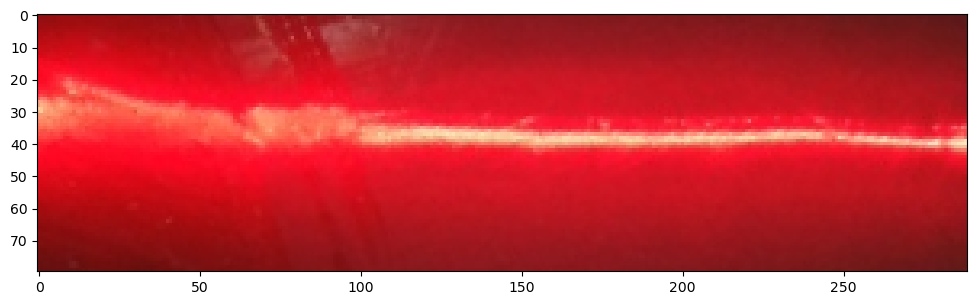

In [ ]:
%matplotlib inline
i = 1946 #random.randint(0, len(photos)-1) #273
path = folder + photos[i]
print(path)
img = preprocess_image(path, degree = 26.2)
plt.clf()
plt.figure(figsize=(12, 6))
plt.imshow(img[:, :, ::-1])
plt.show()

In [44]:
import numpy as np
from analyze_five import gaussian

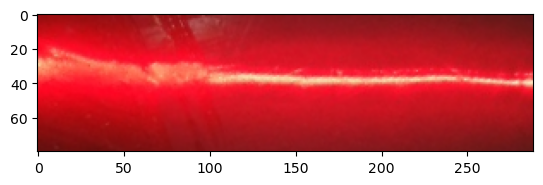

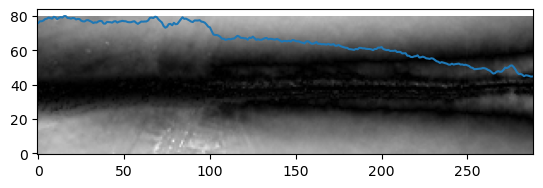

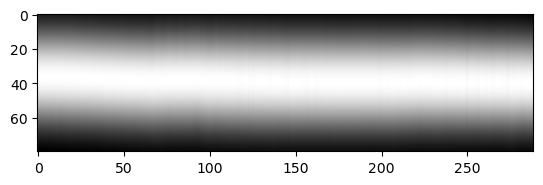

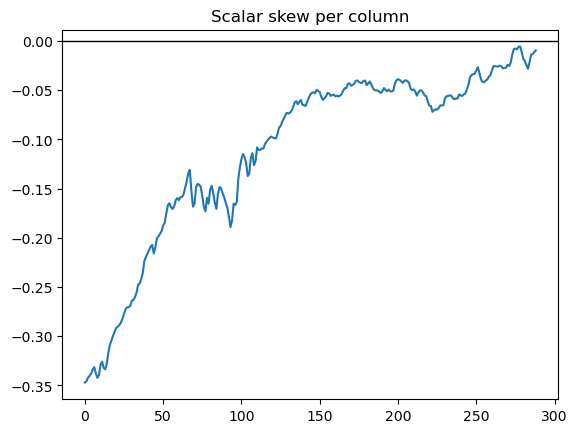

In [72]:
gray = to_gray(img).astype(float)

threshold = 0 #threshold_otsu(gray)
_, binary_stripe = cv2.threshold(gray.astype(np.uint8), threshold, 255, cv2.THRESH_BINARY)

A, mu, s = apply_gaussian_fit_across_columns(rotated=gray, threshold=threshold)

h, w = gray.shape
ys = np.arange(h)
xs = np.arange(w)

r = np.zeros_like(gray, dtype=float)
fits = np.zeros_like(gray, dtype=float)
rs = np.zeros(w, dtype=float)
skews = np.zeros(w, dtype=float)

for i in range(w):
    intensities = gray[:, i].astype(float)

    fit = gaussian(ys, A[i], mu[i], s[i])
    fits[:, i] = fit

    res = intensities - fit
    r[:, i] = np.abs(res)
    rs[i] = np.sum(np.abs(res))

    total = np.sum(intensities) + 1e-9
    skews[i] = np.sum(intensities * ((ys - 40) ** 3)) / total / ((s[i] ** 3) + 1e-9)

plt.imshow(img[:, :, ::-1])
plt.show()

plt.imshow(r, cmap='gray')
plt.plot(xs, rs * 80 / (np.max(rs) + 1e-9))
plt.gca().invert_yaxis()
plt.show()

plt.imshow(fits, cmap='gray')
plt.show()

plt.plot(xs, skews)
plt.axhline(0, color='k', linewidth=1)
plt.title("Scalar skew per column")
plt.show()

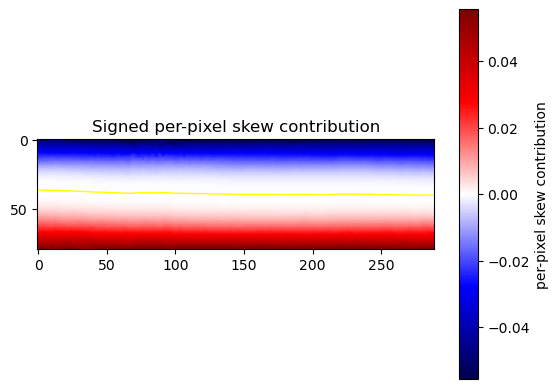

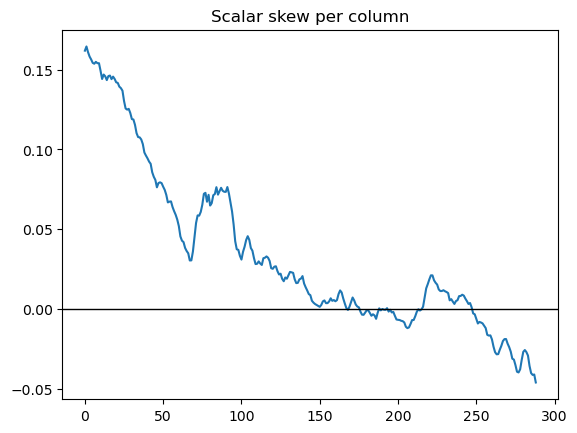

In [74]:


h, w = gray.shape
ys = np.arange(h)
xs = np.arange(w)

skew_contrib = np.zeros_like(gray, dtype=float)
skew_scalar = np.zeros(w, dtype=float)

for i in range(w):
    intensities = gray[:, i].astype(float)

    total = np.sum(intensities) + 1e-9
    sigma = s[i] + 1e-9

    contrib = intensities * ((ys - mu[i]) ** 3) / total / (sigma ** 3)

    skew_contrib[:, i] = contrib
    skew_scalar[i] = np.sum(contrib)

# symmetric signed display around zero
v = np.percentile(np.abs(skew_contrib), 99)

plt.imshow(
    skew_contrib,
    cmap="seismic",
    norm=TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
)
plt.colorbar(label="per-pixel skew contribution")
plt.plot(xs, mu, color="yellow", linewidth=1)
plt.title("Signed per-pixel skew contribution")
plt.show()

plt.plot(xs, skew_scalar)
plt.axhline(0, color="black", linewidth=1)
plt.title("Scalar skew per column")
plt.show()

segments: [(0, 37), (63, 83), (157, 202), (258, 286)]
labels: ['other', 'other', 'other', 'filament']
best_split: {'segment_index': 2, 'filament_start': 157, 'filament_end': 202, 'split_start': 157, 'split_end': 170, 'split_center': 163.5, 'split_confidence': 0.0, 'is_split': False, 'label': 'other', 'features': {'start': 157, 'end': 202, 'length': 46, 'mean_sigma': 5.177573903747227, 'mean_sigma_proc': 5.697346298590951, 'frac_sigma': 0.046464609736070445, 'mean_R': 252.54347826086956, 'mean_G': 62.95652173913044, 'mean_B': 62.67391304347826, 'red_ratio': 4.011395027560592}, 'coefficients': {'a0': -0.006533937994390726, 'a1': -0.9171149134635925, 'a2': 0.016988251358270645, 'a3': 0.4377956986427307}, 'linear_score': 0.0, 'linear_over_cubic': 0.0, 'ratio_score': 0.0, 'r2': 0.9989494874218132, 'r2_score': 1.0, 'support_score': 0.6726015046238899, 'filament_support': 1.0044983625411987, 'evidence_support': 0.282308965921402, 'two_peak_support': 1.0, 'sigma_support': 0.0, 'brightness_supp

<Figure size 640x480 with 0 Axes>

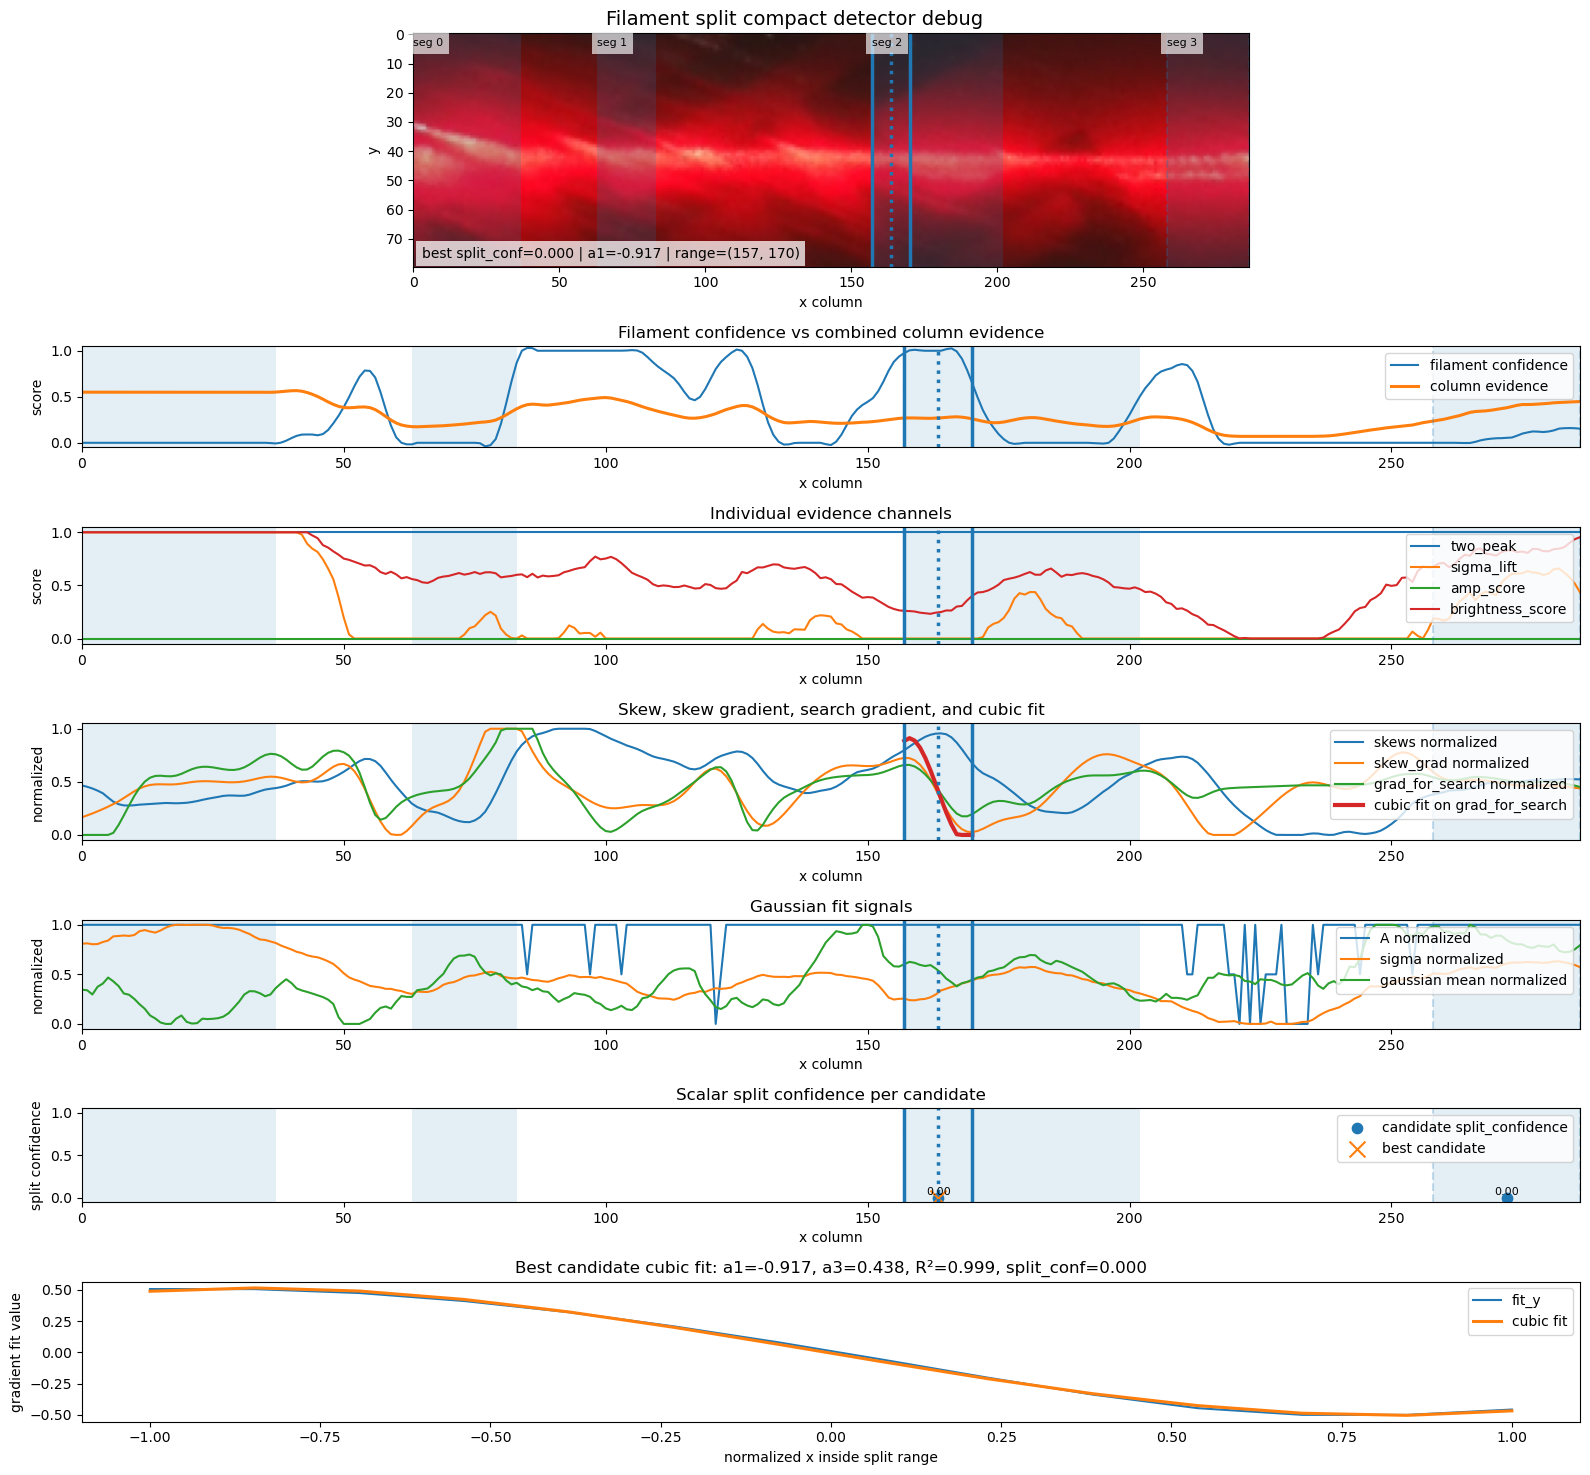

In [14]:
plt.clf()
result = detect_filament_split(img, laser_y=42, window_radius=40, debug=True)
fig, ax = plot_filament_split_result(img, result, show=True)

In [ ]:

def apply_single_mrsac_kernel(img_gray, widths, region_name="B"):
    """
    Apply one MRSAC kernel across the entire image.

    region_name:
        "A" -> use region A template
        "B" -> use region B/C template
        "C" -> same as B/C template
    """
    if region_name.upper() == "A":
        kernel = make_mrsac_template_regionA(widths)
    else:
        kernel = make_mrsac_template_regionB(widths)

    filtered = convolve2d(
        img_gray.astype(np.float32),
        kernel,
        mode="same",
        boundary="symm"
    )

    return filtered, kernel

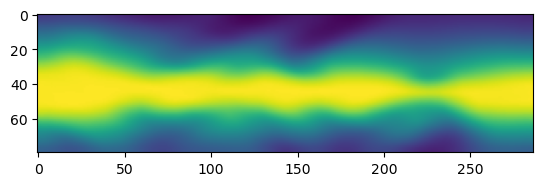

NameError: name 'cv2' is not defined

In [8]:
widths = np.full(gray.shape[1], 9)
filtered, kernel = apply_single_mrsac_kernel(gray, widths, region_name="B")
plt.clf()
plt.imshow(filtered)
plt.show()
kernel = np.ones((1, 15), np.float32) / 9
img_blend_x = cv2.filter2D(gray, -1, kernel)
plt.imshow(gray)
plt.show()

In [ ]:

def column_linewidths(gray):
    threshold = threshold_otsu(gray)
    _, binary_stripe = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    h, w = binary_stripe.shape
    widths = np.zeros(w, dtype=np.int32)
    for j in range(w):
        col = binary_stripe[:, j] > 0
        if not col.any():
            widths[j] = 0
            continue
        top = np.argmax(col)
        bottom = h - 1 - np.argmax(col[::-1])
        widths[j] = max(0, bottom - top + 1)
    return widths

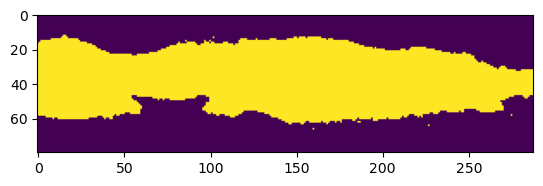

In [ ]:
widths = column_linewidths(gray)
plt.clf()
plt.imshow(widths)
plt.show()